In [146]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [147]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame

In [148]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [149]:
df = df[df['target'] !=0 ][["sepal width (cm)", "petal length (cm)", "target"]]

In [150]:
df.head()

,sepal width (cm),petal length (cm),target
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


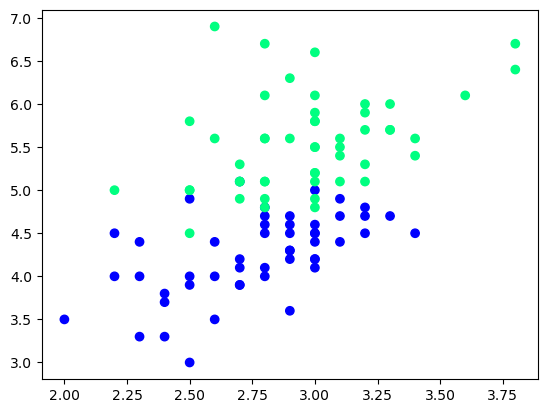

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(df['sepal width (cm)'],df['petal length (cm)'], c=df['target'],cmap='winter')


In [152]:
df.shape

(100, 3)

In [153]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [154]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [155]:
X_test

array([[2.8, 4. ],
       [2.8, 5.1],
       [2.8, 4.5],
       [2.8, 6.1],
       [3. , 6.6]])

In [156]:
y_test

array([1, 2, 1, 2, 2])

In [157]:
#  Tree 1

df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


,sepal width (cm),petal length (cm),target
138,3.0,4.8,2
93,2.3,3.3,1
138,3.0,4.8,2
93,2.3,3.3,1
67,2.7,4.1,1
67,2.7,4.1,1
138,3.0,4.8,2
138,3.0,4.8,2


In [158]:
X

,sepal width (cm),petal length (cm)
138,3.0,4.8
93,2.3,3.3
138,3.0,4.8
93,2.3,3.3
67,2.7,4.1
67,2.7,4.1
138,3.0,4.8
138,3.0,4.8


In [159]:
y

138    2
93     1
138    2
93     1
67     1
67     1
138    2
138    2
Name: target, dtype: int64

In [160]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

In [161]:
dt_bag1 = DecisionTreeClassifier()

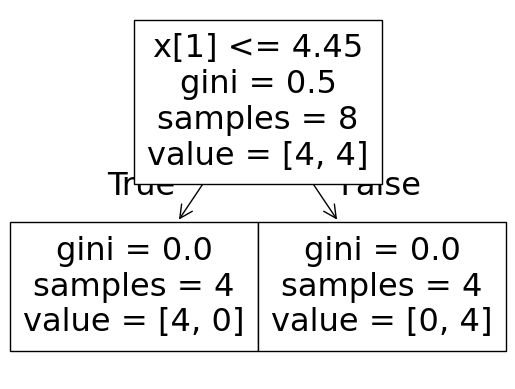

0.8


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


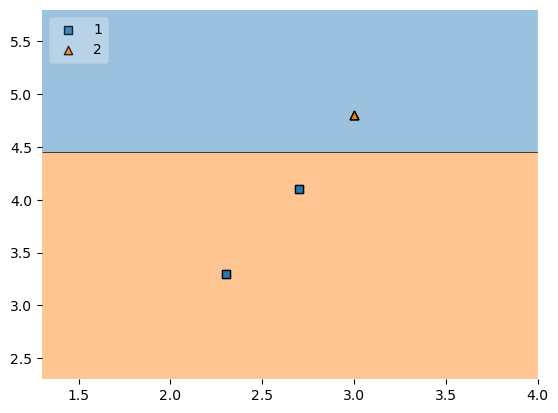

In [162]:
evaluate(dt_bag1,X,y)

In [163]:
#  Tree 2

df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


,sepal width (cm),petal length (cm),target
67,2.7,4.1,1
134,2.6,5.6,2
123,2.7,4.9,2
93,2.3,3.3,1
84,3.0,4.5,1
118,2.6,6.9,2
93,2.3,3.3,1
84,3.0,4.5,1


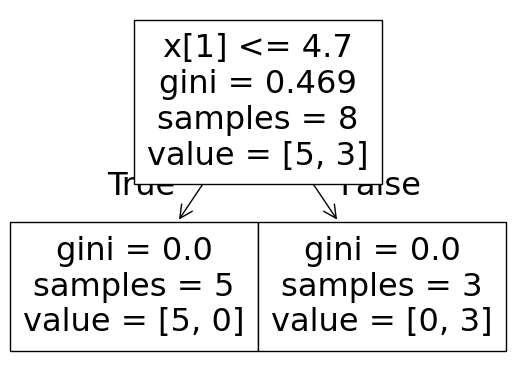

1.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


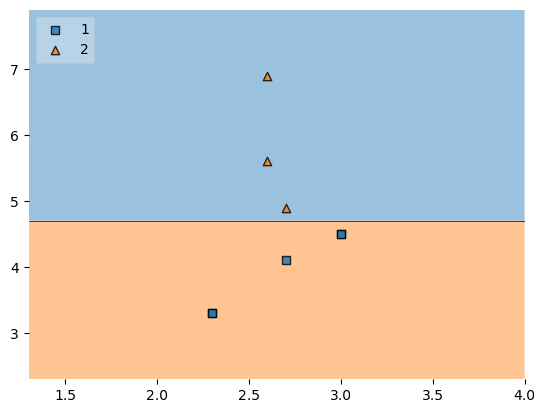

In [164]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [166]:
#  Tree 3

df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


,sepal width (cm),petal length (cm),target
118,2.6,6.9,2
102,3.0,5.9,2
93,2.3,3.3,1
84,3.0,4.5,1
138,3.0,4.8,2
123,2.7,4.9,2
84,3.0,4.5,1
96,2.9,4.2,1


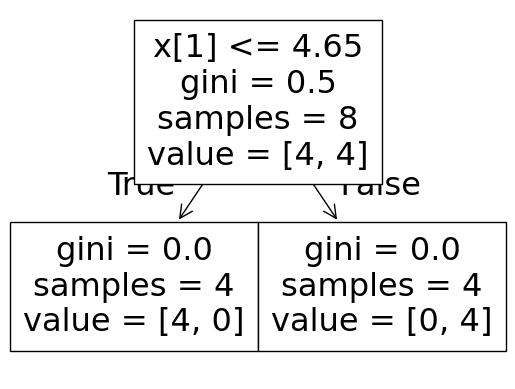

1.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


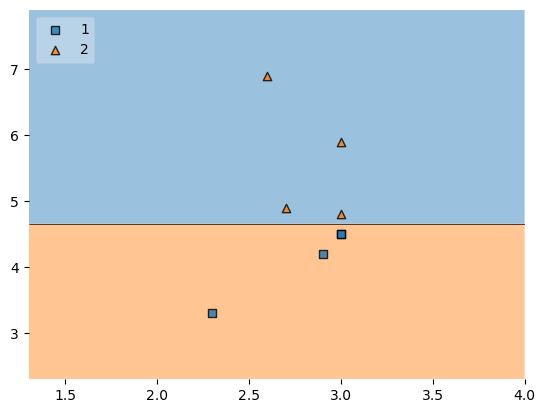

In [171]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [172]:
df_test

,sepal width (cm),petal length (cm),target
127,3.0,4.9,2
75,3.0,4.4,1
73,2.8,4.7,1
141,3.1,5.1,2
113,2.5,5.0,2


In [174]:
import numpy as np
print("Predictor 1",dt_bag1.predict(np.array([3.0,4.9]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,4.9]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,4.9]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [177]:
import numpy as np
print("Predictor 1",dt_bag1.predict(np.array([2.8,4.7]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.8,4.7]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.8,4.7]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#### Pasting 

- row sampling without replacement, replace=False ( by default )

In [179]:
df_train.sample(8)

,sepal width (cm),petal length (cm),target
96,2.9,4.2,1
134,2.6,5.6,2
123,2.7,4.9,2
118,2.6,6.9,2
93,2.3,3.3,1
68,2.2,4.5,1
102,3.0,5.9,2
84,3.0,4.5,1


#### Random Subspace

- colomn sampling, with or without replace = true

In [184]:
iris = load_iris(as_frame=True)
df1 = iris.frame

df1.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
67,5.8,2.7,4.1,1.0,1
138,6.0,3.0,4.8,1.8,2
21,5.1,3.7,1.5,0.4,0
141,6.9,3.1,5.1,2.3,2
4,5.0,3.6,1.4,0.2,0
42,4.4,3.2,1.3,0.2,0
117,7.7,3.8,6.7,2.2,2
12,4.8,3.0,1.4,0.1,0
108,6.7,2.5,5.8,1.8,2
105,7.6,3.0,6.6,2.1,2


In [186]:
df1.sample(2, replace=True,axis=1)


,sepal width (cm),sepal length (cm)
0,3.5,5.1
1,3.0,4.9
2,3.2,4.7
3,3.1,4.6
4,3.6,5.0
...,...,...
145,3.0,6.7
146,2.5,6.3
147,3.0,6.5
148,3.4,6.2


#### Random Patches
- both row and colomn sampling

In [191]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal length (cm),petal width (cm)
29,4.7,0.2
48,5.3,0.2
38,4.4,0.2
98,5.1,1.1
7,5.0,0.2
73,6.1,1.2
2,4.7,0.2
43,5.0,0.6
